In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from datetime import date

from aquacrop import AquaCrop, Crop, Soil, Weather

from aquacrop_slovenia import config
from aquacrop_slovenia.diagnostics import print_metrics
from aquacrop_slovenia.parameters_running_jablje import (
    jablje_curve_number,
    jablje_initial_cond,
    jablje_maize_params,
    jablje_optimal_management,
    jablje_readily_evaporable_water,
    jablje_soil_layers,
)
from aquacrop_slovenia.plots import (
    plot_yield_scatter,
    plot_yield_timeseries_comparison,
    plot_yield_timeseries_residuals,
)
from aquacrop_slovenia.reading_data import (
    get_co2_for_aquacrop,
    get_station_weather,
    get_yield,
    get_yield_for_comparison,
)

Loaded data sizes: Temperatures=1096, ETo=1096, Rain=1096


In [3]:
LOCATION = "jablje"

simulation_periods = [
    {
        "start_date": date(year, 1, 1),
        "end_date": date(year, 12, 31),
        "planting_date": date(year, 5, 3),
        "is_seeding_year": True,
    }
    for year in range(1993, 2024)
    if year != 2017
]

historical_co2 = get_co2_for_aquacrop("historical")

maize = Crop(
    name=f"{LOCATION} maize",
    description=f"{LOCATION} maize uncalibrated",
    params=jablje_maize_params,
)

soil = Soil(
    name=f"{LOCATION} soil",
    description=f"{LOCATION} soil uncalibrated",
    soil_layers=jablje_soil_layers,
    curve_number=jablje_curve_number,
    readily_evaporable_water=jablje_readily_evaporable_water,
)

In [4]:
temperatures_8, eto_8, rain_8 = get_station_weather(8)
temperatures_9, eto_9, rain_9 = get_station_weather(9)

weather_8 = Weather(
    location=LOCATION,
    temperatures=temperatures_8,
    eto_values=eto_8,
    rainfall_values=rain_8,
    record_type=1,
    first_day=1,
    first_month=1,
    first_year=1993,
    co2_records=historical_co2,
)

weather_9 = Weather(
    location=LOCATION,
    temperatures=temperatures_9,
    eto_values=eto_9,
    rainfall_values=rain_9,
    record_type=1,
    first_day=1,
    first_month=1,
    first_year=1993,
    co2_records=historical_co2,
)

In [5]:
# Compare raw weather inputs between the two stations
df8 = pd.DataFrame(temperatures_8, columns=["tmin", "tmax"])
df8["eto"] = eto_8
df8["rain"] = rain_8

df9 = pd.DataFrame(temperatures_9, columns=["tmin", "tmax"])
df9["eto"] = eto_9
df9["rain"] = rain_9

print(f"Station 8 — {len(df8)} records")
display(df8.describe().round(2))
print(f"\nStation 9 — {len(df9)} records")
display(df9.describe().round(2))

Station 8 — 11322 records


,tmin,tmax,eto,rain
count,11322.00,11322.00,11322.00,11322.00
mean,4.27,15.62,1.97,3.66
std,7.63,9.42,1.66,9.49
min,-23.70,-9.10,0.00,0.00
25%,-1.60,8.10,0.50,0.00
50%,4.70,16.10,1.40,0.00
75%,10.70,23.30,3.30,1.90
max,20.80,38.10,7.20,227.10



Station 9 — 11322 records


,tmin,tmax,eto,rain
count,11322.00,11322.00,11322.00,11322.00
mean,4.27,15.62,1.95,3.66
std,7.63,9.42,1.59,9.49
min,-23.70,-9.10,0.00,0.00
25%,-1.60,8.10,0.50,0.00
50%,4.70,16.10,1.50,0.00
75%,10.70,23.30,3.10,1.90
max,20.80,38.10,7.00,227.10


In [6]:
out_8 = config.MODEL_RUNNING_DIR / "station_compare_jablje_8"
out_8.mkdir(parents=True, exist_ok=True)

sim_8 = AquaCrop(
    simulation_periods=simulation_periods,
    crop=maize,
    soil=soil,
    management=jablje_optimal_management,
    initial_conditions=jablje_initial_cond,
    climate=weather_8,
    working_dir=out_8,
    need_daily_output=False,
    need_seasonal_output=True,
    need_harvest_output=False,
    need_evaluation_output=False,
)
seasonal_8 = sim_8.run()["season"]
print("Station 8 done")

Setting up working directory at: E:\aquacrop\station_compare_jablje_8
Running AquaCrop simulation with project file: E:\aquacrop\station_compare_jablje_8\LIST\PROJECT.PRM
Detected platform: windows (AMD64)
Looking for executable at: C:\Users\rokku\Documents\Code\aquacrop-slovenia\.venv\Lib\site-packages\model\windows\aquacrop.exe
Using AquaCrop executable: E:\aquacrop\station_compare_jablje_8\aquacrop.exe
AquaCrop simulation completed successfully
Parsing simulation results...
Results successfully parsed
Station 8 done


In [7]:
out_9 = config.MODEL_RUNNING_DIR / "station_compare_jablje_9"
out_9.mkdir(parents=True, exist_ok=True)

sim_9 = AquaCrop(
    simulation_periods=simulation_periods,
    crop=maize,
    soil=soil,
    management=jablje_optimal_management,
    initial_conditions=jablje_initial_cond,
    climate=weather_9,
    working_dir=out_9,
    need_daily_output=False,
    need_seasonal_output=True,
    need_harvest_output=False,
    need_evaluation_output=False,
)
seasonal_9 = sim_9.run()["season"]
print("Station 9 done")

Setting up working directory at: E:\aquacrop\station_compare_jablje_9
Running AquaCrop simulation with project file: E:\aquacrop\station_compare_jablje_9\LIST\PROJECT.PRM
Detected platform: windows (AMD64)
Looking for executable at: C:\Users\rokku\Documents\Code\aquacrop-slovenia\.venv\Lib\site-packages\model\windows\aquacrop.exe
Using AquaCrop executable: E:\aquacrop\station_compare_jablje_9\aquacrop.exe
AquaCrop simulation completed successfully
Parsing simulation results...
Results successfully parsed
Station 9 done


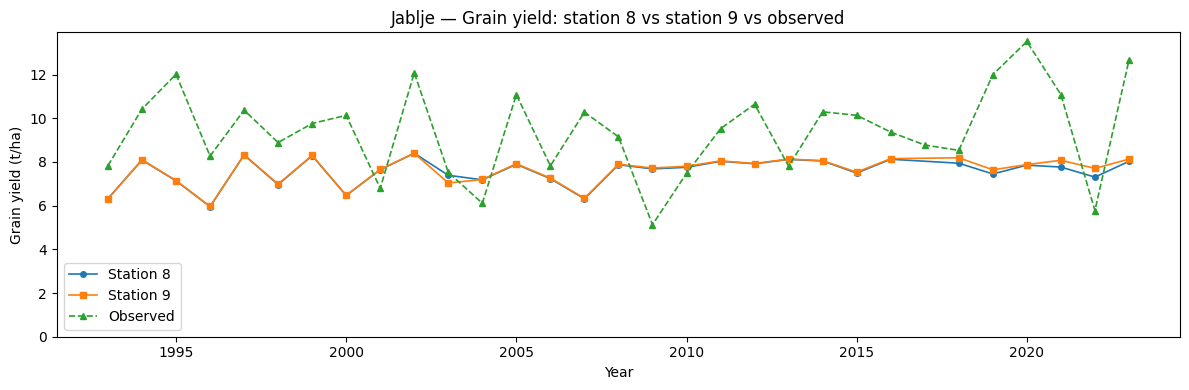

In [8]:
obs_grain = get_yield(LOCATION, "grain", "A", "N3")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(seasonal_8["Year1"], seasonal_8["Y(dry)"], marker="o", markersize=4, linewidth=1.2, label="Station 8")
ax.plot(seasonal_9["Year1"], seasonal_9["Y(dry)"], marker="s", markersize=4, linewidth=1.2, label="Station 9")
ax.plot(obs_grain["year"], obs_grain["yield"], marker="^", markersize=4, linewidth=1.2, linestyle="--", label="Observed")
ax.set_ylim(bottom=0)
ax.set_xlabel("Year")
ax.set_ylabel("Grain yield (t/ha)")
ax.set_title("Jablje — Grain yield: station 8 vs station 9 vs observed")
ax.legend()
plt.tight_layout()
plt.show()

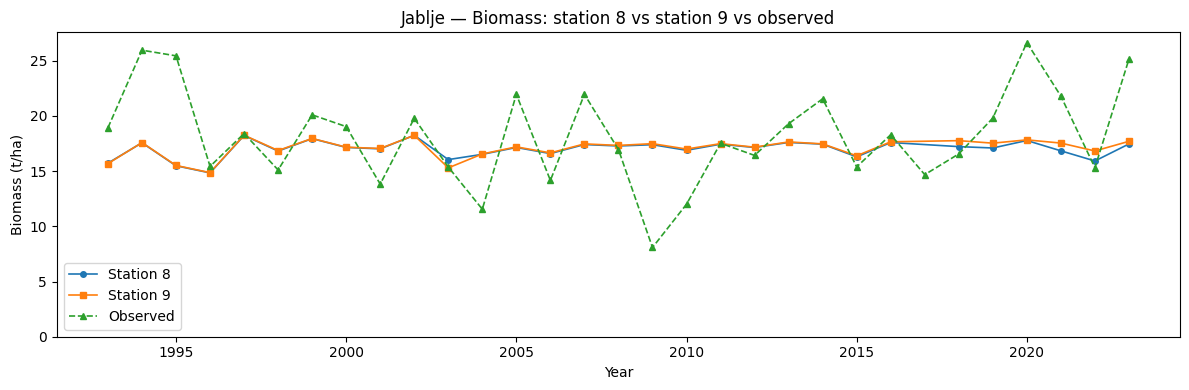

In [9]:
obs_biomass = get_yield(LOCATION, "biomass", "A", "N3")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(seasonal_8["Year1"], seasonal_8["BioMass"], marker="o", markersize=4, linewidth=1.2, label="Station 8")
ax.plot(seasonal_9["Year1"], seasonal_9["BioMass"], marker="s", markersize=4, linewidth=1.2, label="Station 9")
ax.plot(obs_biomass["year"], obs_biomass["yield"], marker="^", markersize=4, linewidth=1.2, linestyle="--", label="Observed")
ax.set_ylim(bottom=0)
ax.set_xlabel("Year")
ax.set_ylabel("Biomass (t/ha)")
ax.set_title("Jablje — Biomass: station 8 vs station 9 vs observed")
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
obs_grain_cmp = get_yield_for_comparison(LOCATION, "grain", "A", "N3")
print("=== Grain — Station 8 ===")
print_metrics(seasonal_8, obs_grain_cmp, "Y(dry)", "Grain")
print("\n=== Grain — Station 9 ===")
print_metrics(seasonal_9, obs_grain_cmp, "Y(dry)", "Grain")

=== Grain — Station 8 ===
=== Grain ===
  RMSE:       2.7165
  R2:         -0.7526
  NSE:        -0.7526
  KGE:        -0.0408
  mKGE:       0.0075
  KGE_r:      0.2498
  KGE_beta:   0.8036
  KGE_alpha:  0.3058
  mKGE_alpha: 0.3806

=== Grain — Station 9 ===
=== Grain ===
  RMSE:       2.6893
  R2:         -0.7177
  NSE:        -0.7177
  KGE:        -0.0355
  mKGE:       0.0124
  KGE_r:      0.2467
  KGE_beta:   0.8083
  KGE_alpha:  0.3158
  mKGE_alpha: 0.3907


In [11]:
obs_biomass_cmp = get_yield_for_comparison(LOCATION, "biomass", "A", "N3")
print("=== Biomass — Station 8 ===")
print_metrics(seasonal_8, obs_biomass_cmp, "BioMass", "Biomass")
print("\n=== Biomass — Station 9 ===")
print_metrics(seasonal_9, obs_biomass_cmp, "BioMass", "Biomass")

=== Biomass — Station 8 ===
=== Biomass ===
  RMSE:       4.4031
  R2:         -0.0283
  NSE:        -0.0283
  KGE:        -0.1176
  mKGE:       -0.1079
  KGE_r:      0.2435
  KGE_beta:   0.9313
  KGE_alpha:  0.1802
  mKGE_alpha: 0.1935

=== Biomass — Station 9 ===
=== Biomass ===
  RMSE:       4.3692
  R2:         -0.0126
  NSE:        -0.0126
  KGE:        -0.1071
  mKGE:       -0.0977
  KGE_r:      0.2475
  KGE_beta:   0.9369
  KGE_alpha:  0.1905
  mKGE_alpha: 0.2033


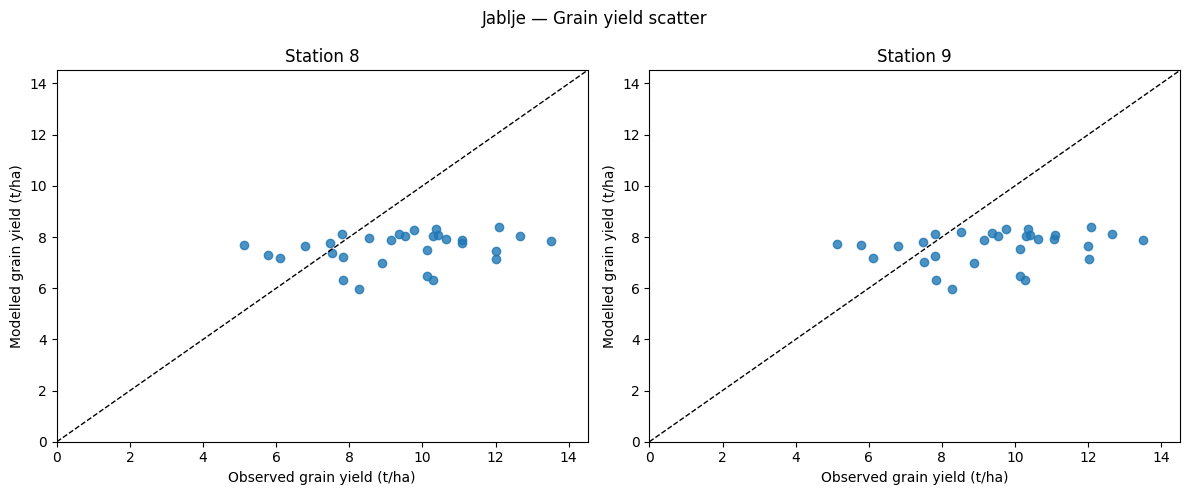

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, seasonal, label in [(axes[0], seasonal_8, "Station 8"), (axes[1], seasonal_9, "Station 9")]:
    merged = obs_grain_cmp.merge(
        seasonal[["Year1", "Y(dry)"]].rename(columns={"Year1": "year", "Y(dry)": "modeled"}),
        on="year",
    )
    lim = [0, max(merged["yield"].max(), merged["modeled"].max()) + 1]
    ax.scatter(merged["yield"], merged["modeled"], alpha=0.8)
    ax.plot(lim, lim, "k--", lw=1)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("Observed grain yield (t/ha)")
    ax.set_ylabel("Modelled grain yield (t/ha)")
    ax.set_title(label)

fig.suptitle("Jablje — Grain yield scatter")
plt.tight_layout()
plt.show()

Station 8 — grain residuals
Station 9 — grain residuals


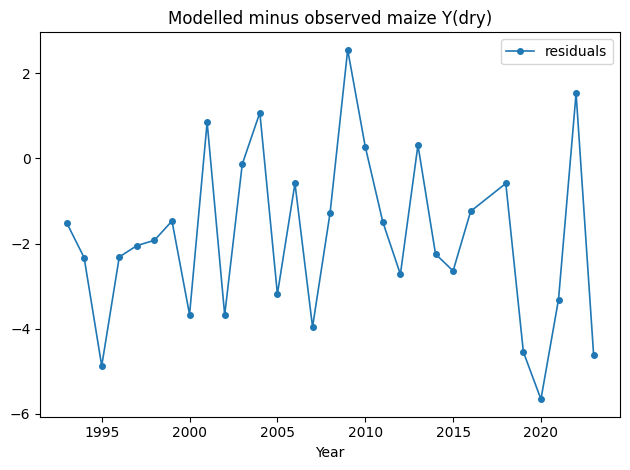

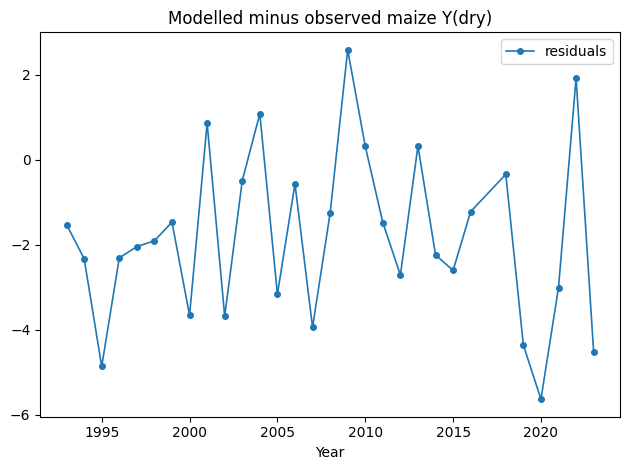

In [13]:
print("Station 8 — grain residuals")
plot_yield_timeseries_residuals(seasonal_8, obs_grain_cmp, "Y(dry)")
print("Station 9 — grain residuals")
plot_yield_timeseries_residuals(seasonal_9, obs_grain_cmp, "Y(dry)")

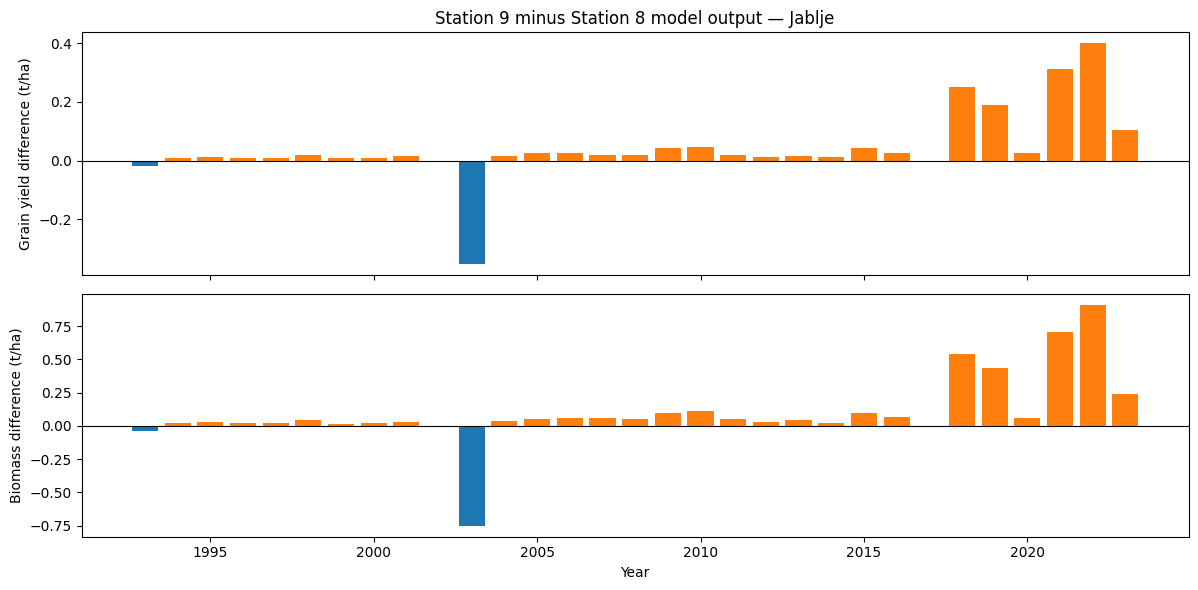

Mean grain diff (st9 - st8): 0.044 t/ha
Mean biomass diff:           0.102 t/ha


In [14]:
# Direct difference between station 9 and station 8 model outputs
diff = seasonal_8[["Year1"]].copy()
diff["grain_diff"] = seasonal_9["Y(dry)"].values - seasonal_8["Y(dry)"].values
diff["biomass_diff"] = seasonal_9["BioMass"].values - seasonal_8["BioMass"].values

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for ax, col, label in [
    (axes[0], "grain_diff",   "Grain yield difference (t/ha)"),
    (axes[1], "biomass_diff", "Biomass difference (t/ha)"),
]:
    ax.bar(diff["Year1"], diff[col], color=["C1" if v > 0 else "C0" for v in diff[col]])
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylabel(label)

axes[0].set_title("Station 9 minus Station 8 model output — Jablje")
axes[1].set_xlabel("Year")
plt.tight_layout()
plt.show()

print(f"Mean grain diff (st9 - st8): {diff['grain_diff'].mean():.3f} t/ha")
print(f"Mean biomass diff:           {diff['biomass_diff'].mean():.3f} t/ha")